In [3]:
#Arithmetic Brownian Motion
#Recoded in Python by: Henry Wingrove

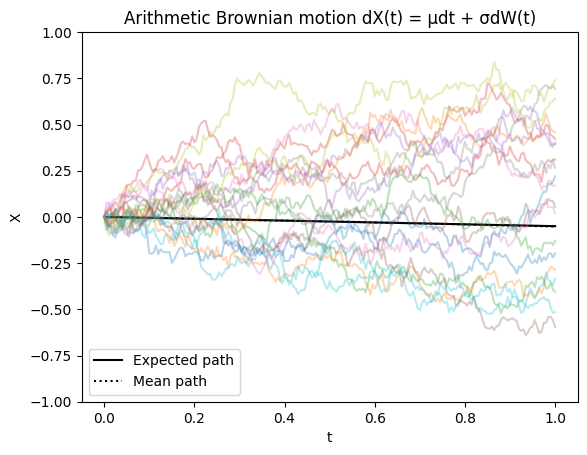

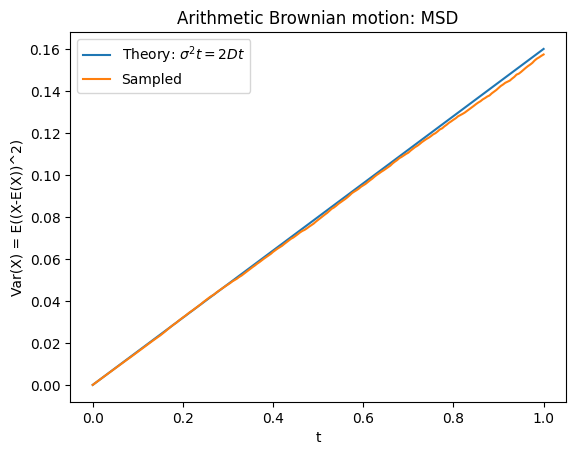

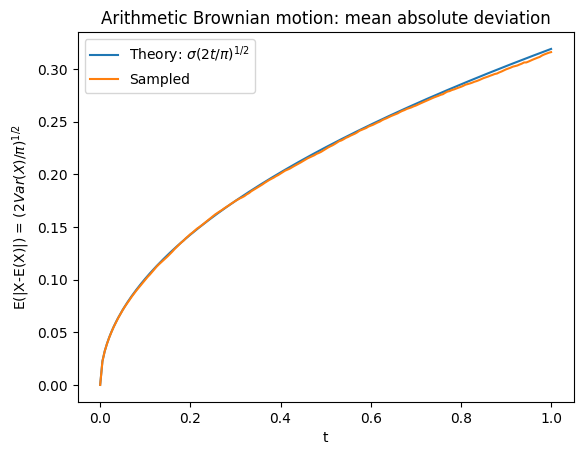

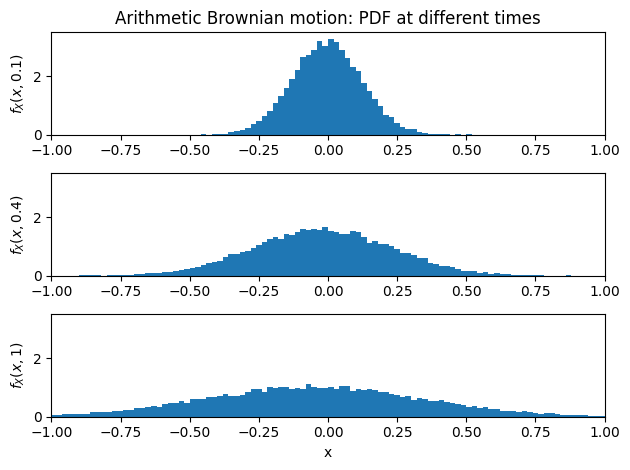

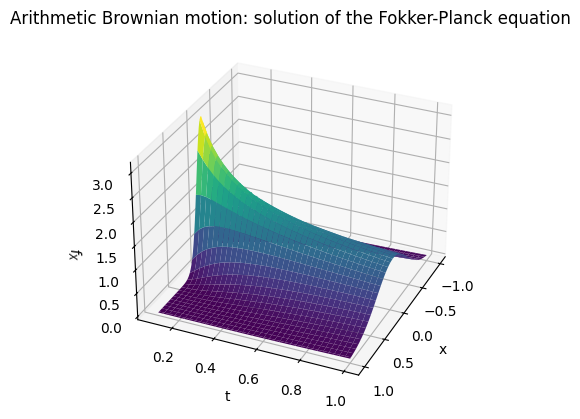

In [127]:
import numpy as np
import matplotlib.pyplot as plt

# Monte Carlo simulation of arithmetic Brownian motion
# dX(t) = mu*dt + sigma*dW(t)

# Define parameters and time grid
npaths = 20000  # number of paths
T = 1  # time horizon
nsteps = 200  # number of time steps
dt = T / nsteps  # time step
t = np.linspace(0, T, nsteps + 1)  # observation times
mu = -0.05  # drift
sigma = 0.4  # volatility

# Monte Carlo Simulation
# Compute the increments with Euler-Maruyama
dX = mu * dt + sigma * np.random.randn(npaths, nsteps) * np.sqrt(dt)

# Accumulate the increments
X = np.hstack([np.zeros((npaths, 1)), np.cumsum(dX, axis=1)])  # Start paths at 0

# Plot Expected Path, Mean Path, and Sample Paths
plt.figure(1)
EX = mu * t  # expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, X.mean(axis=0), ':k', label='Mean path')
plt.plot(t, X[::1000, :].T, alpha=0.3)  # Plot fewer sample paths for clarity
plt.legend()
plt.xlabel('t')
plt.ylabel('X')
plt.ylim([-1, 1])
plt.title('Arithmetic Brownian motion dX(t) = μdt + σdW(t)')
plt.savefig('abmpaths.png')

# Variance = mean square deviation = mean square displacement
plt.figure(2)
plt.plot(t, sigma**2 * t, label=r'Theory: $\sigma^2 t = 2Dt$')
plt.plot(t, X.var(axis=0), label='Sampled')
plt.legend(loc='upper left')
plt.xlabel('t')
plt.ylabel(r'Var(X) = E((X-E(X))^2)')
plt.title('Arithmetic Brownian motion: MSD')
plt.savefig('abmmsd.png')
# Mean absolute deviation
plt.figure(3)

# Calculate mean absolute deviation
mean_absolute_deviation = np.mean(np.abs(X - EX), axis=0)
plt.plot(t, sigma * np.sqrt(2 * t / np.pi), label=r'Theory: $\sigma(2t/\pi)^{1/2}$')
plt.plot(t, mean_absolute_deviation, label='Sampled')
plt.legend(loc='upper left')  # Fix legend position
plt.xlabel('t')
plt.ylabel(r'E(|X-E(X)|) = $(2Var(X)/\pi)^{1/2}$')
plt.ylim([0, 0.02])  # Adjust y-axis limits for better visibility
plt.autoscale()
plt.title('Arithmetic Brownian motion: mean absolute deviation')
plt.savefig('mad.png')

# Probability density function at different times
plt.figure(4)

plt.subplot(3, 1, 1)
plt.hist(X[:, 20], bins=np.arange(-1, 1.02, 0.02), density=True)
plt.ylabel(r'$f_X(x,0.1)$')
plt.xlim([-1, 1])
plt.ylim([0, 3.5])
plt.title('Arithmetic Brownian motion: PDF at different times')

plt.subplot(3, 1, 2)
plt.hist(X[:, 80], bins=np.arange(-1, 1.02, 0.02), density=True)
plt.ylabel(r'$f_X(x,0.4)$')
plt.xlim([-1, 1])
plt.ylim([0, 3.5])

plt.subplot(3, 1, 3)
plt.hist(X[:, -1], bins=np.arange(-1, 1.02, 0.02), density=True)
plt.xlabel('x')
plt.ylabel(r'$f_X(x,1)$')
plt.xlim([-1, 1])
plt.ylim([0, 3.5])

plt.tight_layout()
plt.savefig('abmhist.png')

# Solution of the Fokker-Planck equation
plt.figure(5)
D = sigma**2 / 2  # diffusion coefficient
x, tt = np.meshgrid(np.arange(-1, 1.02, 0.02), np.arange(0.1, 1.025, 0.025))
f = 1 / (2 * np.sqrt(np.pi * D * tt)) * np.exp(-((x - mu * tt)**2) / (4 * D * tt))

ax = plt.axes(projection='3d')
ax.plot_surface(x, tt, f, cmap='viridis', edgecolor='none')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel(r'$f_X$')
ax.set_title('Arithmetic Brownian motion: solution of the Fokker-Planck equation')
ax.view_init(30, 24)
plt.savefig('abmfpe.png')

plt.show()